# 01 — Data Exploration

## Project
Cross-Lingual Procurement Product Classification

## Objective
To explore the dataset before modeling

## Questions
1. Is the dataset balanced?
2. Are there duplicates?
3. Are there category labels identifiable from simple keywords?
4. Are there potentially ambiguous or difficult examples?

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('../data/raw/products.csv')
df.head(10)

,id,language,product,category
0,1,id,laptop Lenovo ThinkPad X1 Carbon Gen 11,IT
1,2,id,PC desktop Dell OptiPlex 7010 Tower,IT
2,3,id,monitor eksternal ASUS ProArt PA278CV,IT
3,4,id,mini PC ASUS ExpertCenter PN64,IT
4,5,id,router Wi-Fi kantor TP-Link Archer AX90 (AX6600),IT
5,6,id,network switch Cisco CBS250-24T-4G,IT
6,7,id,network attached storage (NAS) Synology DiskSt...,IT
7,8,id,printer multi-fungsi HP LaserJet Pro MFP M428fdn,IT
8,9,id,scanner dokumen Epson WorkForce DS-530 II,IT
9,10,id,keyboard wireless Logitech MX Keys S,IT


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        200 non-null    int64
 1   language  200 non-null    str  
 2   product   200 non-null    str  
 3   category  200 non-null    str  
dtypes: int64(1), str(3)
memory usage: 6.4 KB


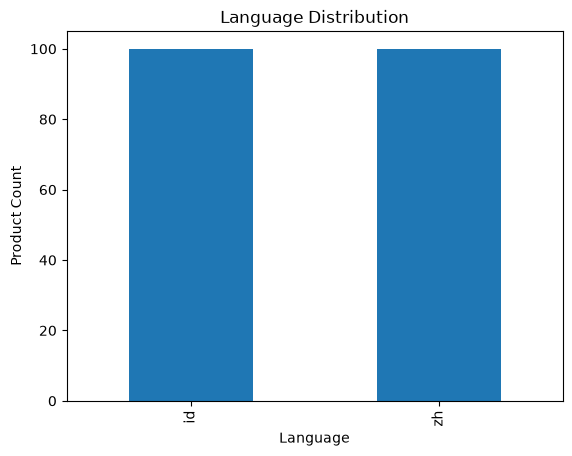

In [7]:
df['language'].value_counts().plot(kind='bar')

plt.title('Language Distribution')
plt.xlabel('Language')
plt.ylabel('Product Count')
plt.show()

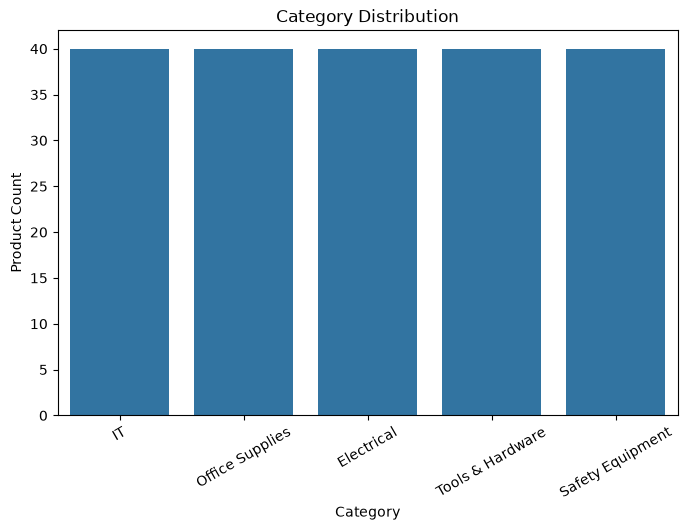

In [8]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='category',
    order=df['category'].value_counts().index
)

plt.title('Category Distribution')
plt.xlabel('Category')
plt.ylabel('Product Count')
plt.xticks(rotation=30)
plt.show()

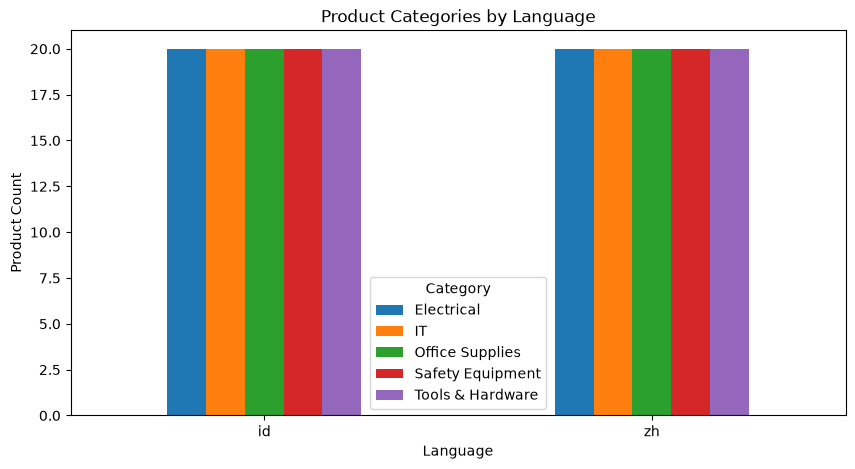

In [9]:
cross_tab = pd.crosstab(df['language'], df['category'])

cross_tab.plot(kind='bar', figsize=(10, 5))

plt.title('Product Categories by Language')
plt.xlabel('Language')
plt.ylabel('Product Count')
plt.xticks(rotation=0)
plt.legend(title='Category')
plt.show()

In [10]:
pd.set_option('display.max_colwidth', None)

df[df['language'] == 'id'][['product', 'category']].head(30)

,product,category
0,laptop Lenovo ThinkPad X1 Carbon Gen 11,IT
1,PC desktop Dell OptiPlex 7010 Tower,IT
2,monitor eksternal ASUS ProArt PA278CV,IT
3,mini PC ASUS ExpertCenter PN64,IT
4,router Wi-Fi kantor TP-Link Archer AX90 (AX6600),IT
5,network switch Cisco CBS250-24T-4G,IT
6,network attached storage (NAS) Synology DiskStation DS923+,IT
7,printer multi-fungsi HP LaserJet Pro MFP M428fdn,IT
8,scanner dokumen Epson WorkForce DS-530 II,IT
9,keyboard wireless Logitech MX Keys S,IT


In [11]:
pd.set_option('display.max_colwidth', None)

df[df['language'] == 'zh'][['product', 'category']].head(30)

,product,category
100,安全帽ABS/HDPE,Safety Equipment
101,防护眼镜,Safety Equipment
102,防噪音耳塞,Safety Equipment
103,防降噪耳罩,Safety Equipment
104,防尘口罩KN95 / N95,Safety Equipment
105,防毒面具,Safety Equipment
106,安全鞋耐200J冲击,Safety Equipment
107,反光背心120g经编布,Safety Equipment
108,防割手套,Safety Equipment
109,化学防护服,Safety Equipment


In [12]:
df[df['product'].duplicated(keep=False)].sort_values('product')

,id,language,product,category


In [13]:
from collections import Counter
import re

id_df = df[df['language'] == 'id']

words = []

for text in id_df['product']:
    words.extend(re.findall(r'\b\w+\b', text.lower()))

word_counts = Counter(words)

word_counts.most_common(30)

[('kertas', 7),
 ('lampu', 6),
 ('listrik', 5),
 ('dan', 4),
 ('kabel', 4),
 ('dinding', 4),
 ('tangan', 4),
 ('pro', 3),
 ('logitech', 3),
 ('ukuran', 3),
 ('inci', 3),
 ('led', 3),
 ('alat', 3),
 ('kunci', 3),
 ('sarung', 3),
 ('11', 2),
 ('pc', 2),
 ('eksternal', 2),
 ('asus', 2),
 ('network', 2),
 ('switch', 2),
 ('epson', 2),
 ('wireless', 2),
 ('mx', 2),
 ('ultra', 2),
 ('ruang', 2),
 ('rapat', 2),
 ('ups', 2),
 ('microsoft', 2),
 ('a4', 2)]

In [14]:
zh_df = df[df['language'] == 'zh']

chars = []

for text in zh_df['product']:
    chars.extend(list(text))

char_counts = Counter(chars)

char_counts.most_common(30)

[('电', 15),
 ('机', 15),
 ('0', 13),
 ('全', 9),
 (' ', 9),
 ('胶', 8),
 ('笔', 8),
 ('防', 7),
 ('5', 7),
 ('1', 7),
 ('安', 6),
 ('B', 6),
 ('/', 6),
 ('式', 6),
 ('器', 6),
 ('工', 6),
 ('本', 6),
 ('P', 5),
 ('手', 5),
 ('带', 5),
 ('线', 5),
 ('锁', 5),
 ('动', 5),
 ('能', 5),
 ('脑', 5),
 ('体', 5),
 ('S', 4),
 ('耳', 4),
 ('4', 4),
 ('7', 4)]

In [15]:
for category in sorted(df['category'].unique()):
    print('\n' + '=' * 60)
    print(category)
    print('=' * 60)

    display(
        df[df['category'] == category][
            ['language', 'product']
        ].sort_values('language')
    )


Electrical


,language,product
40,id,kabel instalasi dalam dinding PVC
58,id,lampu sorot tanam untuk koridor
57,id,lampu petunjuk jalur evakuasi
56,id,sakelar putar/sentuh
55,id,kipas penyedot udara
54,id,alat pemantau suhu dan kelembapan
53,id,smart socket
52,id,digital thermo-hygrometer dinding
51,id,stabilizer listrik
50,id,kipas angin dinding



IT


,language,product
0,id,laptop Lenovo ThinkPad X1 Carbon Gen 11
18,id,sistem operasi bisnis Microsoft Windows 11 Pro
17,id,fingerprint dan akses kontrol Secure X100-C
16,id,hard disk eksternal (backup) WD My Passport Ultra 2TB
15,id,uninterruptible power supply (UPS) APC Back-UPS Pro BR1500GI
14,id,proyektor ruang rapat Epson EB-E500
13,id,speakerphone ruang rapat Anker PowerConf S3
12,id,webcam meeting Logitech Brio 4K Ultra HD
11,id,headset komunikasi Jabra Evolve2 65
10,id,mouse wireless Logitech MX Master 3S



Office Supplies


,language,product
20,id,pulpen hitam/biru
38,id,dispenser selotip meja
37,id,buku agenda ukran A5
36,id,lem kertas
35,id,bantalan stempel dan tinta ukuran sedang
34,id,lakban bening
33,id,map tulang ukuran A4
32,id,pelubang kertas
31,id,spidol whiteboard
30,id,spidol permanen



Safety Equipment


,language,product
80,id,helm proyek
98,id,kerucut lalu lintas
97,id,pencuci mata darurat
96,id,alat pemadam api ringan (APAR)
95,id,rompi keselamatan high-visibility
94,id,tali penyerap hentakan
93,id,tali pengaman seluruh tubuh
92,id,sepatu safety
91,id,sarung tangan isolasi listrik
90,id,sarung tangan tahan kimia



Tools & Hardware


,language,product
60,id,bor tanpa kabel
78,id,mesin las listrik
77,id,pipa besi
76,id,gembok pagar
75,id,baut angkur dinding
74,id,kotak perkakas
73,id,waterpas 24 inci
72,id,meteran laser
71,id,meteran gulung
70,id,kunci L
